In [1]:
# Slide 15
# Image Data
# https://www.imageprocessingplace.com/DIP-3E/dip3e_book_images_downloads.htm

import cv2
import numpy as np
import matplotlib.pyplot as plt

15.1 – Structuring Element Generation (Square, Cross, Disk)

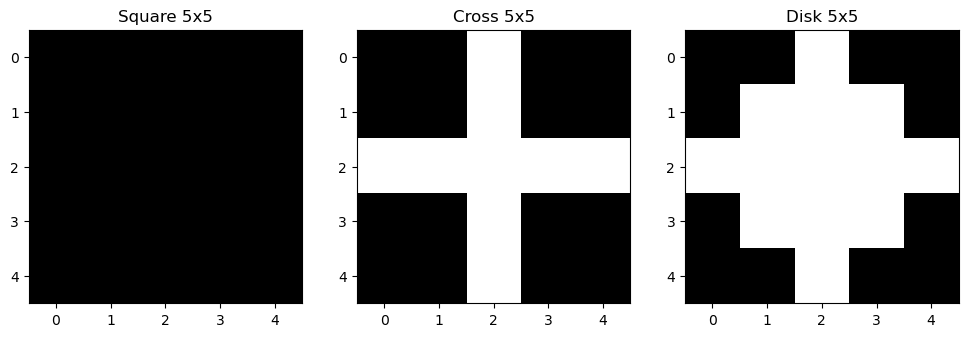

In [2]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0905(a)(wirebond-mask).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Square SE
se_sq = np.ones((5, 5), dtype=np.uint8)

# Cross SE
se_cross = np.zeros((5, 5), dtype=np.uint8)
se_cross[2, :] = 1
se_cross[:, 2] = 1

# Disk SE
y, x = np.ogrid[-2:3, -2:3]
se_disk = (x*x + y*y <= 4).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(se_sq, cmap='gray'); plt.title('Square 5x5')
plt.subplot(1, 3, 2); plt.imshow(se_cross, cmap='gray'); plt.title('Cross 5x5')
plt.subplot(1, 3, 3); plt.imshow(se_disk, cmap='gray'); plt.title('Disk 5x5')
plt.show()

15.2 – Binary Erosion Operation (manual)

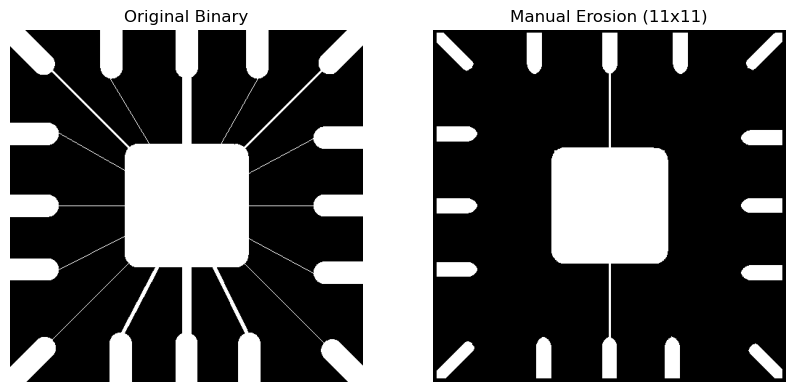

In [3]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0905(a)(wirebond-mask).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

se = np.ones((11, 11), dtype=np.uint8)
h, w = binary.shape
sh, sw = se.shape
eroded = np.zeros_like(binary)

pad_h, pad_w = sh // 2, sw // 2
padded = np.pad(binary, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

for i in range(h):
    for j in range(w):
        window = padded[i:i+sh, j:j+sw]
        if np.all(window[se == 1] == 255):
            eroded[i, j] = 255

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Original Binary'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(eroded, cmap='gray'); plt.title('Manual Erosion (11x11)'); plt.axis('off')
plt.show()

15.3 – Binary Dilation Operation (manual)

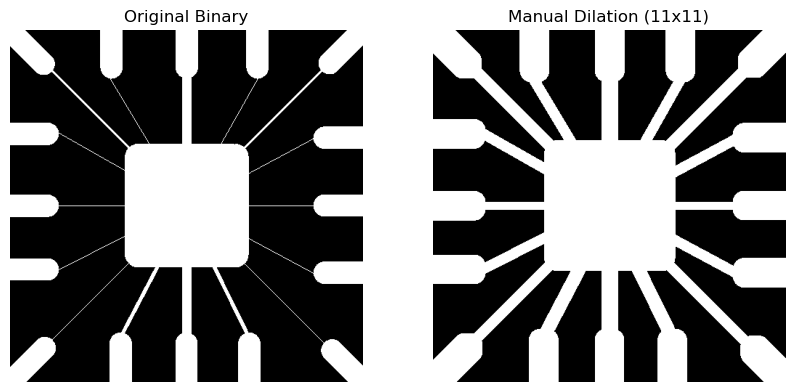

In [4]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0905(a)(wirebond-mask).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

se = np.ones((11, 11), dtype=np.uint8)
h, w = binary.shape
sh, sw = se.shape
dilated = np.zeros_like(binary)

pad_h, pad_w = sh // 2, sw // 2
padded = np.pad(binary, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

for i in range(h):
    for j in range(w):
        window = padded[i:i+sh, j:j+sw]
        if np.any(window[se == 1] == 255):
            dilated[i, j] = 255

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Original Binary'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(dilated, cmap='gray'); plt.title('Manual Dilation (11x11)'); plt.axis('off')
plt.show()

15.4 – Hit-or-Miss Transform (Fit & Hit concept)

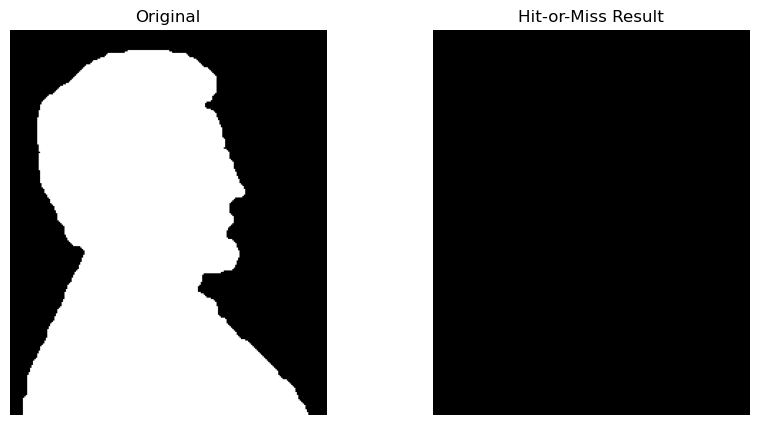

In [5]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0914(a)(licoln from penny).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Custom SE for detecting specific corners/patterns
se_hit = np.array([[0, 0, 0], [0, 1, 1], [0, 1, 0]], dtype=np.uint8)
se_miss = np.array([[1, 1, 1], [1, 0, 0], [1, 0, 1]], dtype=np.uint8)

def erode_manual(image, kernel):
    res = np.zeros_like(image)
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode='constant')
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            if np.all(padded[i:i+kh, j:j+kw][kernel == 1] == 255):
                res[i, j] = 255
    return res

hit = erode_manual(binary, se_hit)
miss = erode_manual(255 - binary, se_miss)
hit_miss = cv2.bitwise_and(hit, miss)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(hit_miss, cmap='gray'); plt.title('Hit-or-Miss Result'); plt.axis('off')
plt.show()

15.5 – Opening Operation (Erosion followed by Dilation)

[ WARN:0@4.440] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@4.440] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@4.440] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@4.440] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@4.440] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@4.440] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@4.440] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@4.440] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

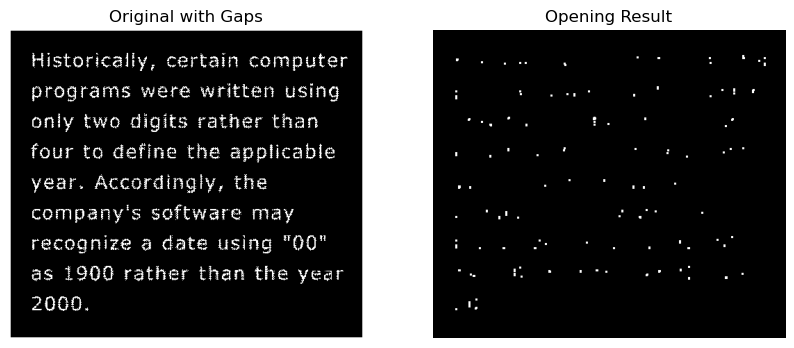

In [6]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0907(a)(text_gaps_1_and_2_pixels).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

se = np.ones((3, 3), dtype=np.uint8)
eroded = cv2.erode(binary, se)
opened = cv2.dilate(eroded, se)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Original with Gaps'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(opened, cmap='gray'); plt.title('Opening Result'); plt.axis('off')
plt.show()

15.6 – Closing Operation (Dilation followed by Erosion)

[ WARN:0@4.562] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@4.562] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@4.562] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@4.562] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@4.562] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@4.562] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@4.562] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@4.562] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

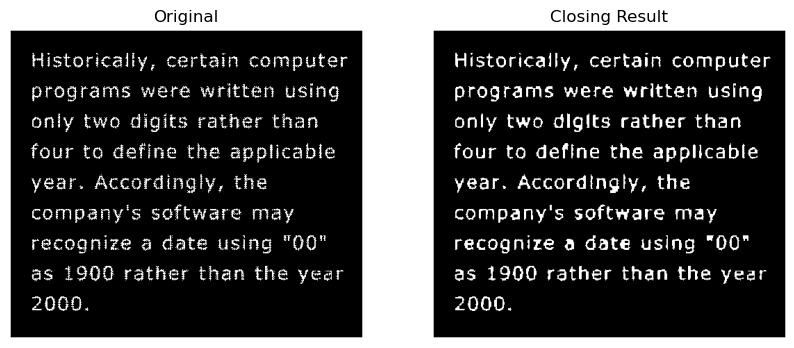

In [7]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0907(a)(text_gaps_1_and_2_pixels).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

se = np.ones((3, 3), dtype=np.uint8)
dilated = cv2.dilate(binary, se)
closed = cv2.erode(dilated, se)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(closed, cmap='gray'); plt.title('Closing Result'); plt.axis('off')
plt.show()

15.7 – Morphological Boundary Extraction

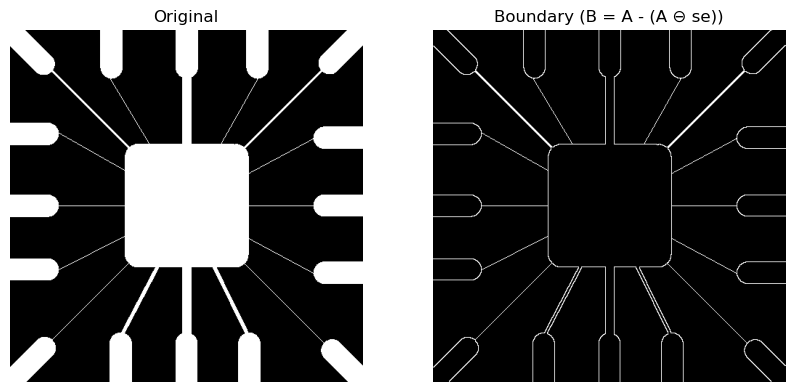

In [8]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0905(a)(wirebond-mask).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

se = np.ones((3, 3), dtype=np.uint8)
eroded = cv2.erode(binary, se)
boundary = binary - eroded

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(boundary, cmap='gray'); plt.title('Boundary (B = A - (A ⊖ se))'); plt.axis('off')
plt.show()

15.8 – Region Filling using Dilation

[ WARN:0@4.776] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


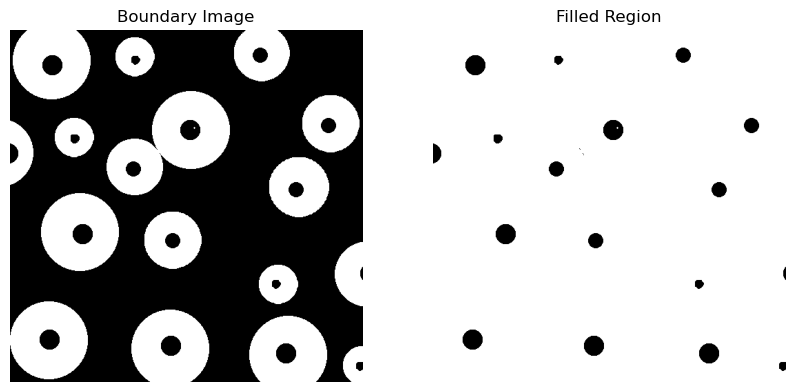

In [9]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0916(a)(region-filling-reflections).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Complement of boundary
binary_inv = 255 - binary
# Starting seed point (estimated center of a hole)
seed = np.zeros_like(binary)
seed[150, 150] = 255

se = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=np.uint8)
X_prev = seed
while True:
    X_curr = cv2.dilate(X_prev, se)
    X_curr = cv2.bitwise_and(X_curr, binary_inv)
    if np.array_equal(X_curr, X_prev):
        break
    X_prev = X_curr

filled = cv2.bitwise_or(binary, X_curr)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Boundary Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(filled, cmap='gray'); plt.title('Filled Region'); plt.axis('off')
plt.show()

15.9 – Connected Component Labeling (basic)

[ WARN:0@4.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@4.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@4.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@4.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@4.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@4.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@4.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@4.913] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

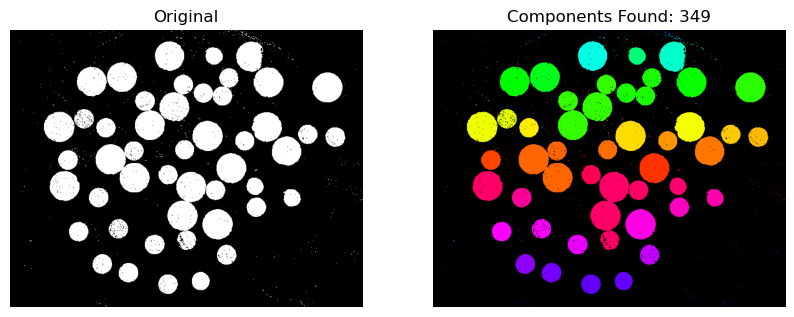

In [10]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0941(a)(wood_dowels).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

num_labels, labels = cv2.connectedComponents(binary)

# Map labels to colors for visualization
label_hue = np.uint8(179 * labels / np.max(labels))
blank_ch = 255 * np.ones_like(label_hue)
labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
labeled_img[label_hue == 0] = 0

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(labeled_img); plt.title(f'Components Found: {num_labels-1}'); plt.axis('off')
plt.show()

15.10 – Thinning / Skeletonization (basic morphological algorithm)

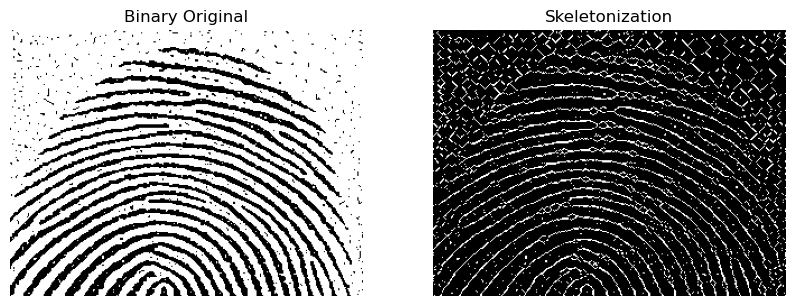

In [11]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0911(a)(noisy_fingerprint).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

skeleton = np.zeros_like(binary)
se = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
temp_img = binary.copy()

while True:
    eroded = cv2.erode(temp_img, se)
    dilated = cv2.dilate(eroded, se)
    subset = cv2.subtract(temp_img, dilated)
    skeleton = cv2.bitwise_or(skeleton, subset)
    temp_img = eroded.copy()
    if cv2.countNonZero(temp_img) == 0:
        break

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Binary Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(skeleton, cmap='gray'); plt.title('Skeletonization'); plt.axis('off')
plt.show()

15.11 – Morphological Noise Removal / Cleaning (using Opening + Closing)

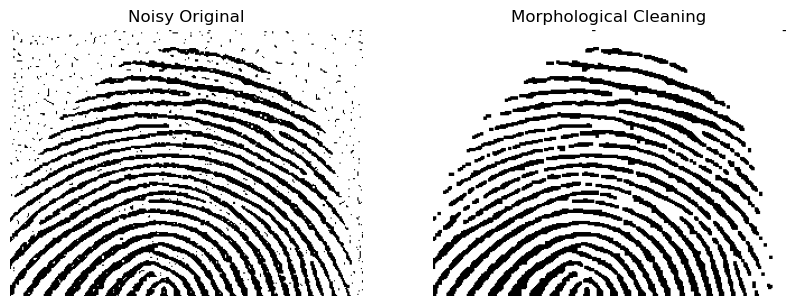

In [12]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0911(a)(noisy_fingerprint).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

se = np.ones((3, 3), dtype=np.uint8)
# Remove white noise (Opening)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, se)
# Remove black noise (Closing)
cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, se)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Noisy Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cleaned, cmap='gray'); plt.title('Morphological Cleaning'); plt.axis('off')
plt.show()

15.12 – Full Morphological Pipeline Comparison

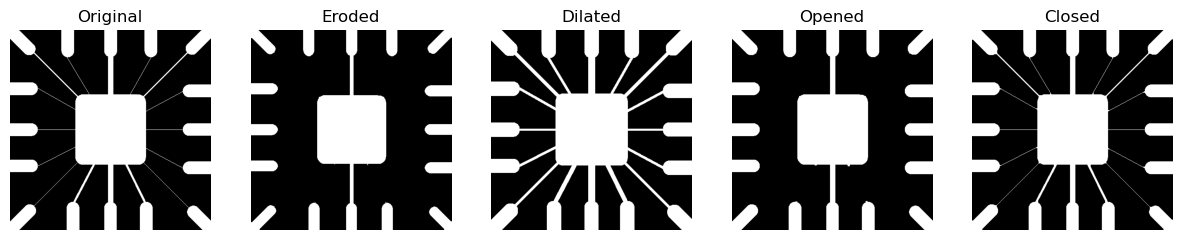

In [13]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0905(a)(wirebond-mask).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, b = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
se = np.ones((5, 5), np.uint8)

res = [b, cv2.erode(b, se), cv2.dilate(b, se), cv2.morphologyEx(b, cv2.MORPH_OPEN, se), cv2.morphologyEx(b, cv2.MORPH_CLOSE, se)]
titles = ['Original', 'Eroded', 'Dilated', 'Opened', 'Closed']

plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(1, 5, i+1); plt.imshow(res[i], cmap='gray'); plt.title(titles[i]); plt.axis('off')
plt.show()

15.13 – Structuring Element Effect Visualization (3x3 vs 5x5 vs disk)

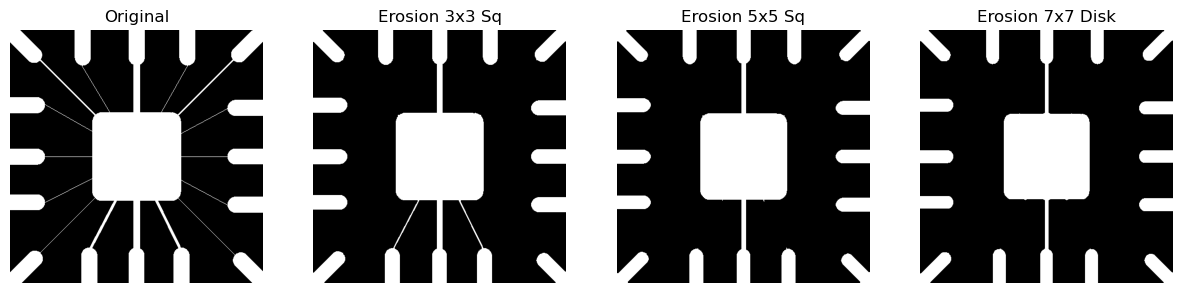

In [14]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0905(a)(wirebond-mask).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

se3 = np.ones((3, 3), np.uint8)
se5 = np.ones((5, 5), np.uint8)
se_disk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

e3 = cv2.erode(binary, se3)
e5 = cv2.erode(binary, se5)
edisk = cv2.erode(binary, se_disk)

plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1); plt.imshow(binary, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1, 4, 2); plt.imshow(e3, cmap='gray'); plt.title('Erosion 3x3 Sq'); plt.axis('off')
plt.subplot(1, 4, 3); plt.imshow(e5, cmap='gray'); plt.title('Erosion 5x5 Sq'); plt.axis('off')
plt.subplot(1, 4, 4); plt.imshow(edisk, cmap='gray'); plt.title('Erosion 7x7 Disk'); plt.axis('off')
plt.show()

15.14 – Image Reconstruction using Morphological Operations

[ WARN:0@5.621] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


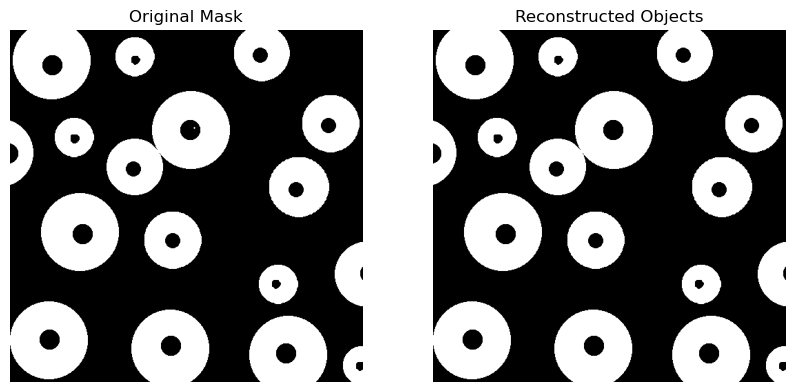

In [15]:
# Load the image
image_path = 'DIP3E_Original_Images_CH09/Fig0916(a)(region-filling-reflections).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Marker: Eroded image
se = np.ones((15, 15), np.uint8)
marker = cv2.erode(binary, se)
mask = binary.copy()

# Reconstruction by dilation
recon = marker.copy()
se_recon = np.ones((3, 3), np.uint8)
for _ in range(100):
    prev = recon.copy()
    recon = cv2.dilate(recon, se_recon)
    recon = cv2.bitwise_and(recon, mask)
    if np.array_equal(recon, prev):
        break

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Original Mask'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(recon, cmap='gray'); plt.title('Reconstructed Objects'); plt.axis('off')
plt.show()